In [2]:
# Notebook 4 — Phase B Knowledge Graph: Dáil Co-occurrence Pipeline
#
# Builds a new KG from Irish parliamentary debate transcripts using entity
# co-occurrence within sentences, rather than Wikidata property lookup.
# Trains TransE embeddings on the resulting triples and reruns the 20-seed
# gaBERT-CRF NER experiment for direct comparison with Phase A (Notebook 2).
#
# Data sources:
#   - Herzog et al. Dáil debates 1919–2013 (Harvard Dataverse)
#   - ParlEE Irish parliamentary speeches 2009–2019 (Harvard Dataverse)
#   - Adkins et al. 2025 Irish NER corpus (entity vocabulary)
#   - Phase 2/3 node CSVs (surface_to_qid, QID grounding)
#
# Pipeline:
#   Cell 1  : Overview (this cell)
#   Cell 2  : Dependencies and imports
#   Cell 3  : Load and inspect both datasets
#   Cell 4  : Herzog preprocessing (sentence splitting)
#   Cell 5  : ParlEE preprocessing
#   Cell 6  : Entity vocabulary and surface_to_qid
#   Cell 7  : Co-occurrence extraction — Herzog
#   Cell 8  : Co-occurrence extraction — ParlEE
#   Cell 9  : Triple combination, deduplication, frequency filtering
#   Cell 10 : QID grounding diagnostic
#   Cell 11 : PyKEEN TransE training
#   Cell 12 : UMAP diagnostic
#   Cell 13 : Edge density report
#   Cell 14 : 20-seed gaBERT-CRF training loop
#   Cell 15 : Statistical tests (one-sample + two-sample Wilcoxon)
#   Cell 16 : XAI replication
#   Cell 17 : Phase A vs Phase B comparison table

In [3]:
# CELL 2 
# Dependencies and imports

!pip install -q pykeen nltk umap-learn
!pip install -q pytorch-crf

import os
import gc
import json
import random
import pickle
from itertools import combinations
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm import tqdm

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import BertTokenizer, BertModel, BertConfig, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torchcrf import CRF

from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory

import umap
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import scipy.stats as stats

#  Paths 

HERZOG_PATH    = '/kaggle/input/datasets/michaelmarkey64/herzog-mikhaylov-dail-debates/Dail_debates_1919-2013/Dail_debates_1919-2013.tab'
MINISTERS_PATH = '/kaggle/input/datasets/michaelmarkey64/herzog-mikhaylov-dail-debates/Dail_debates_1937-2011_ministers.tab'
PARLEE_PATH    = '/kaggle/input/datasets/michaelmarkey64/parlee-ie-plenary-speeches/ParlEE_IE_plenary_speeches.csv'

PER_CSV = '/kaggle/input/datasets/michaelmarkey64/kg-embeddings-baseline-dissertation/per_nodes.csv'
LOC_CSV = '/kaggle/input/datasets/michaelmarkey64/kg-embeddings-baseline-dissertation/loc_nodes.csv'
ORG_CSV = '/kaggle/input/datasets/michaelmarkey64/kg-embeddings-baseline-dissertation/org_nodes.csv'

TRAIN_CONLL = '/kaggle/input/datasets/michaelmarkey64/irish-ner-kg-consolidated/conll/train_final.conll'
VALID_CONLL = '/kaggle/input/datasets/michaelmarkey64/irish-ner-kg-consolidated/conll/NER_Irish_validation.conll'
TEST_CONLL  = '/kaggle/input/datasets/michaelmarkey64/irish-ner-kg-consolidated/conll/NER_Irish_test.conll'

PHASE_A_EMBEDDINGS = '/kaggle/input/datasets/michaelmarkey64/kg-embeddings-baseline-dissertation/TransE_qid_embeddings.pkl'
PHASE_A_RESULTS    = '/kaggle/working/wilcoxon_results.json'

# Input paths (read-only)
TRIPLES_HERZOG  = '/kaggle/input/datasets/michaelmarkey64/notebook4-augmentedkgtriples/triples_herzog.tsv'
TRIPLES_PARLEE  = '/kaggle/input/datasets/michaelmarkey64/notebook4-augmentedkgtriples/triples_parlee.tsv'
TRIPLES_PHASE_B = '/kaggle/input/datasets/michaelmarkey64/notebook4-augmentedkgtriples/kg_triples_phase_b.tsv'
EMBEDDINGS_OUT  = '/kaggle/input/datasets/michaelmarkey64/notebook4-augmentedkgtriples/TransE_phase_b_embeddings.pkl'

# Output paths (writable)
RESULTS_CSV  = '/kaggle/working/seed_loop_phase_b_f1_scores.csv'
WILCOXON_OUT = '/kaggle/working/wilcoxon_phase_b_results.json'
EMBEDDINGS_WORKING = '/kaggle/working/TransE_phase_b_embeddings.pkl'

# Constants
PAPER_BASELINE_F1 = 0.7652
FREQ_THRESHOLD    = 3       # minimum co-occurrence count to retain a triple
HERZOG_START_YEAR = 1980    # filter out pre-modern Irish text
KG_DIM            = 128
MAX_LEN           = 256

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.1 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you 

2026-06-08 13:23:20.216775: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780925000.408704      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780925000.459988      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780925000.905681      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780925000.905717      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780925000.905720      58 computation_placer.cc:177] computation placer alr

Device: cuda


In [4]:
# CELL 3
# Load and inspect both datasets
#
# Herzog: tab-separated, one row per speech, quoting=3 required because the
# file uses no quote characters — passing the default quoting setting causes
# pandas to misparse rows with internal tab characters in speech text.
#
# ParlEE: CSV, one row per sentence, already sentence-split.

print("Loading Herzog...")
herzog = pd.read_csv(HERZOG_PATH, sep='\t', quoting=3, low_memory=False)
print(f"  Shape      : {herzog.shape}")
print(f"  Columns    : {herzog.columns.tolist()}")
print(f"  Sample row :")
print(herzog.iloc[0])

print("\nLoading ParlEE...")
parlee = pd.read_csv(PARLEE_PATH, low_memory=False)
print(f"  Shape      : {parlee.shape}")
print(f"  Columns    : {parlee.columns.tolist()}")
print(f"  Sample row :")
print(parlee.iloc[0])

Loading Herzog...


KeyboardInterrupt: 

In [5]:
# CELL 4 
# Herzog preprocessing
#
# Filter to post-1980 speeches to avoid archaic Irish text that won't match
# the Adkins corpus entity vocabulary. Sentence-split each speech using
# nltk sent_tokenize. Output is a flat list of dicts with sentence text
# plus speaker and party metadata preserved.
#
# Runtime: 20-30 minutes on the full 4.4M speech corpus.

herzog['date'] = pd.to_datetime(herzog['date'], errors='coerce')
herzog_filtered = herzog[herzog['date'].dt.year >= HERZOG_START_YEAR].copy()
print(f"Herzog speeches after {HERZOG_START_YEAR}: {len(herzog_filtered):,} of {len(herzog):,}")

herzog_sentences = []
for _, row in tqdm(herzog_filtered.iterrows(), total=len(herzog_filtered), desc="Sentence-splitting Herzog"):
    if not isinstance(row['speech'], str) or len(row['speech'].strip()) == 0:
        continue
    sentences = sent_tokenize(row['speech'])
    for sent in sentences:
        sent = sent.strip()
        if len(sent) > 10:  # skip trivial fragments
            herzog_sentences.append({
                'text'       : sent,
                'speaker'    : row['member_name'],
                'party'      : row['party_name'],
                'date'       : row['date'],
            })

print(f"Total Herzog sentences: {len(herzog_sentences):,}")
print(f"Example: {herzog_sentences[0]}")

Herzog speeches after 1980: 2,529,162 of 4,443,713


Sentence-splitting Herzog:   3%|▎         | 66385/2529162 [00:13<08:30, 4821.39it/s]


KeyboardInterrupt: 

In [10]:
# CELL 5 
# ParlEE preprocessing
#
# ParlEE is already sentence-split (one row per sentence) so no splitting
# needed. Filter to Irish parliament only (iso3country == IRE) as a sanity
# check — the file should already be Ireland-only given the filename, but
# confirm. Standardise column names to match Herzog output for a uniform
# interface in the co-occurrence extraction cells.

print(f"ParlEE countries: {parlee['iso3country'].value_counts().to_dict()}")

parlee_ie = parlee[parlee['iso3country'] == 'IRE'].copy()
print(f"Irish sentences: {len(parlee_ie):,} of {len(parlee):,}")

parlee_sentences = []
for _, row in tqdm(parlee_ie.iterrows(), total=len(parlee_ie), desc="Processing ParlEE"):
    if not isinstance(row['text'], str) or len(row['text'].strip()) == 0:
        continue
    text = row['text'].strip()
    if len(text) > 10:
        parlee_sentences.append({
            'text'   : text,
            'speaker': row['speaker'],
            'party'  : row['party'],
            'date'   : row['date'],
        })

print(f"Total ParlEE sentences: {len(parlee_sentences):,}")
print(f"Example: {parlee_sentences[0]}")

ParlEE countries: {'IRE': 3988025}
Irish sentences: 3,988,025 of 3,988,025


Processing ParlEE: 100%|██████████| 3988025/3988025 [02:52<00:00, 23102.72it/s]

Total ParlEE sentences: 3,945,464
Example: {'text': 'Before coming to the Order of Business, I propose to deal with a number of notices under Standing Order 32.', 'speaker': 'Seamus Kirk', 'party': 'Fianna Fáil', 'date': '17/12/2009'}


In [11]:
# CELL 6
# Entity vocabulary and surface_to_qid
#
# Rebuilds the entity surface form vocabulary from the Adkins corpus CoNLL
# files and the Phase 2/3 node CSVs. This gives two things:
#   1. entity_vocab — the set of all unique entity strings to scan for
#      during co-occurrence extraction
#   2. surface_to_qid — mapping from surface form to Wikidata QID, used
#      in Cell 10 for the grounding diagnostic
#
# The canonicalise_irish function is reproduced from Notebook 1/2 so this
# notebook is self-contained.

def canonicalise_irish(text):
    """Strip Irish morphological mutations to get canonical form."""
    import re
    text = text.strip()
    # Strip definite articles
    text = re.sub(r"^(an |na |an t-|na h-)", "", text, flags=re.IGNORECASE)
    # Strip genitive article d'
    text = re.sub(r"^d'", "", text, flags=re.IGNORECASE)
    # Reverse eclipsis
    eclipsis = {
        "mb": "B", "gc": "C", "nd": "D", "bhf": "F",
        "ng": "G", "bp": "P", "dt": "T"
    }
    lower = text.lower()
    for mut, base in eclipsis.items():
        if lower.startswith(mut):
            text = base + text[len(mut):]
            break
    # Reverse lenition
    lenition = {
        "Bh": "B", "Ch": "C", "Dh": "D", "Fh": "F",
        "Gh": "G", "Mh": "M", "Ph": "P", "Sh": "S", "Th": "T"
    }
    for mut, base in lenition.items():
        if text.startswith(mut):
            text = base + text[len(mut):]
            break
    return text

# ── Load entity vocabulary from CoNLL files 
def parse_conll(filepath):
    entities = []
    current_tokens = []
    current_tag = None
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line == '':
                if current_tokens:
                    entities.append((' '.join(current_tokens), current_tag))
                    current_tokens = []
                    current_tag = None
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            token, tag = parts[0], parts[-1]
            if tag.startswith('B-'):
                if current_tokens:
                    entities.append((' '.join(current_tokens), current_tag))
                current_tokens = [token]
                current_tag = tag[2:]
            elif tag.startswith('I-') and current_tokens:
                current_tokens.append(token)
            else:
                if current_tokens:
                    entities.append((' '.join(current_tokens), current_tag))
                    current_tokens = []
                    current_tag = None
    return entities

all_entities = []
for path in [TRAIN_CONLL, VALID_CONLL, TEST_CONLL]:
    all_entities.extend(parse_conll(path))

entity_vocab = set(e for e, _ in all_entities)
print(f"Unique entity surface forms: {len(entity_vocab):,}")

# Also store canonical forms for matching
canon_to_surface = defaultdict(set)
for surface in entity_vocab:
    canon = canonicalise_irish(surface)
    canon_to_surface[canon].add(surface)

# Build surface_to_qid from Phase 2/3 node CSVs 
surface_to_qid = {}

for csv_path in [PER_CSV, LOC_CSV, ORG_CSV]:
    df = pd.read_csv(csv_path)
    for _, row in df.iterrows():
        qid = row.get('qid', None)
        if pd.isna(qid):
            continue
        for col in ['label_en', 'label_ga', 'surface_form', 'entity']:
            if col in row and isinstance(row[col], str):
                surface_to_qid[row[col].strip()] = qid
                surface_to_qid[canonicalise_irish(row[col].strip())] = qid

print(f"surface_to_qid entries: {len(surface_to_qid):,}")
print(f"Entity vocab sample: {list(entity_vocab)[:10]}")

Unique entity surface forms: 1,865
surface_to_qid entries: 2,146
Entity vocab sample: ['Oifig Aicmithe Scannán na hÉireann', 'Brahe', 'Rúnaíocht Déileála na nGearán', 'Brian Friel', 'Mhícheál Ó Gruagáin', 'Bunscoil Mhic Reachtain', 'National Labour Board', 'Cathaoirleach ar Choiste Dhámhachtain Liteartha Idirnáisiúnta Bhaile Átha Cliath', 'Cláraitheoir na mBreitheanna , Básanna agus Póstaí', 'Eamonn Coyne']


In [12]:
# RECOVERY CELL
# Reload saved outputs from dataset — skips Cells 3-10
# Run this instead of Cells 3-10 when resuming a session

import pickle
import pandas as pd
from collections import defaultdict

# Reload triple files from dataset
herzog_triples = {}
parlee_triples = {}

herzog_df_raw = pd.read_csv(TRIPLES_HERZOG, sep='\t')
for _, row in herzog_df_raw.iterrows():
    herzog_triples[(row['subject'], row['predicate'], row['object'])] = row['count']

parlee_df_raw = pd.read_csv(TRIPLES_PARLEE, sep='\t')
for _, row in parlee_df_raw.iterrows():
    parlee_triples[(row['subject'], row['predicate'], row['object'])] = row['count']

print(f"Herzog triples loaded : {len(herzog_triples):,}")
print(f"ParlEE triples loaded : {len(parlee_triples):,}")

# Reload phase B combined triples
phase_b_df = pd.read_csv(TRIPLES_PHASE_B, sep='\t')
print(f"Phase B triples loaded: {len(phase_b_df):,}")

# Rebuild entity vocab and surface_to_qid by running Cell 6 only
print("\nRun Cell 6 now to rebuild entity_vocab and surface_to_qid.")
print("Then run Cell 11 directly.")

Herzog triples loaded : 23,230
ParlEE triples loaded : 11,158
Phase B triples loaded: 9,622

Run Cell 6 now to rebuild entity_vocab and surface_to_qid.
Then run Cell 11 directly.


In [12]:
# CELL 7
# Co-occurrence extraction — Herzog
#
# For each sentence, scan for entity surface forms from the vocabulary.
# Matching uses both the original surface form and its canonicalised variant
# to handle Irish morphological mutation.
# For any sentence containing two or more matched entities, emit all pairwise
# (entity_A, CO_OCCURS_WITH, entity_B) triples. Triples are undirected —
# (A, B) and (B, A) are deduplicated to (min, max) alphabetically.
# Results are written to triples_herzog.tsv with a frequency count column.
#
# Runtime: 20-40 minutes depending on vocabulary scan method.

# Pre-build a lookup: for each entity, also store its canonical form
entity_lookup = {}
for surface in entity_vocab:
    entity_lookup[surface] = surface
    canon = canonicalise_irish(surface)
    if canon != surface:
        entity_lookup[canon] = surface  # canon -> original surface

def extract_cooccurrences(sentences, desc="Extracting"):
    triple_counts = defaultdict(int)
    for item in tqdm(sentences, desc=desc):
        text = item['text']
        found = set()
        for variant, canonical in entity_lookup.items():
            if variant in text:
                found.add(canonical)
        if len(found) >= 2:
            for a, b in combinations(sorted(found), 2):
                triple_counts[(a, 'CO_OCCURS_WITH', b)] += 1
    return triple_counts

herzog_triples = extract_cooccurrences(herzog_sentences, desc="Herzog co-occurrence")

print(f"Unique triples (Herzog): {len(herzog_triples):,}")
print(f"Top 10 by frequency:")
for triple, count in sorted(herzog_triples.items(), key=lambda x: -x[1])[:10]:
    print(f"  {count:5d}  {triple[0]} — {triple[2]}")

# Save
with open(TRIPLES_HERZOG, 'w', encoding='utf-8') as f:
    f.write("subject\tpredicate\tobject\tcount\n")
    for (s, p, o), count in herzog_triples.items():
        f.write(f"{s}\t{p}\t{o}\t{count}\n")
print(f"Saved {TRIPLES_HERZOG}")

Herzog co-occurrence: 100%|██████████| 12349606/12349606 [1:22:35<00:00, 2492.00it/s]


Unique triples (Herzog): 23,230
Top 10 by frequency:
  118323  Dublin — NA ,
  85403  NA , — Taoiseach
  82951  NA , — nGarda
  55349  Gael — NA ,
  43091  Gael — Ghaeltacht
  40856  Dáil — NA ,
  39759  An Garda Síochána — nGarda
  38708  NA , — Tánaiste
  37328  Éire — Éireann
  36479  NA , — Ord
Saved /kaggle/working/triples_herzog.tsv


In [15]:
# CELL 8
# Co-occurrence extraction — ParlEE (fast regex version)

import re

all_variants = list(entity_lookup.keys())
all_variants.sort(key=len, reverse=True)
pattern = re.compile('|'.join(re.escape(v) for v in all_variants))

def extract_cooccurrences_fast(sentences, desc="Extracting"):
    triple_counts = defaultdict(int)
    for item in tqdm(sentences, desc=desc):
        text = item['text']
        matches = pattern.findall(text)
        if len(matches) >= 2:
            found = set(entity_lookup.get(m, m) for m in matches)
            if len(found) >= 2:
                for a, b in combinations(sorted(found), 2):
                    triple_counts[(a, 'CO_OCCURS_WITH', b)] += 1
    return triple_counts

parlee_triples = extract_cooccurrences_fast(parlee_sentences, desc="ParlEE co-occurrence")

print(f"Unique triples (ParlEE): {len(parlee_triples):,}")
print(f"Top 10 by frequency:")
for triple, count in sorted(parlee_triples.items(), key=lambda x: -x[1])[:10]:
    print(f"  {count:5d}  {triple[0]} — {triple[2]}")

with open(TRIPLES_PARLEE, 'w', encoding='utf-8') as f:
    f.write("subject\tpredicate\tobject\tcount\n")
    for (s, p, o), count in parlee_triples.items():
        f.write(f"{s}\t{p}\t{o}\t{count}\n")
print(f"Saved {TRIPLES_PARLEE}")

ParlEE co-occurrence: 100%|██████████| 3945464/3945464 [44:44<00:00, 1469.69it/s]

Unique triples (ParlEE): 11,158
Top 10 by frequency:
  37736  NA , — Taoiseach
  24073  Dublin — NA ,
  20107  Dáil — NA ,
  16925  HSE — NA ,
  14930  NA , — nGarda
  14506  Fhianna Fáil — NA ,
  11962  NA , — Oireachtas
  10763  NA , — Ord
  10656  NA , — bhFine Gael
  10646  NA , — Tánaiste
Saved /kaggle/working/triples_parlee.tsv


In [18]:
# CELL 9
# Triple combination, deduplication, and cleaning
#
# Steps:
#   1. Load both TSV files
#   2. Filter out noise entities (NA, punctuation fragments, short strings)
#   3. Canonicalise subject and object to collapse lenited/eclipsed variants
#   4. Concatenate and sum counts for duplicate triples
#   5. Filter by minimum frequency threshold
#   6. Report and save

noise_entities = {
    'NA ,', 'Ord', 'nGarda', 'Matt', 'Sheehy', 'Donnelly'
}

# Any entity shorter than 3 characters or containing only punctuation is noise
def is_noise(entity):
    if not isinstance(entity, str):
        return True
    if entity in noise_entities:
        return True
    if len(entity.strip()) < 3:
        return True
    if entity.strip().startswith("'") and len(entity.strip()) < 5:
        return True
    return False

herzog_df = pd.read_csv(TRIPLES_HERZOG, sep='\t')
parlee_df = pd.read_csv(TRIPLES_PARLEE, sep='\t')

print(f"Herzog triples before cleaning : {len(herzog_df):,}")
print(f"ParlEE triples before cleaning : {len(parlee_df):,}")

combined = pd.concat([herzog_df, parlee_df], ignore_index=True)

# Filter noise entities
combined = combined[
    ~combined['subject'].apply(is_noise) &
    ~combined['object'].apply(is_noise)
]
print(f"After noise filter: {len(combined):,}")

# Canonicalise subject and object
combined['subject'] = combined['subject'].apply(canonicalise_irish)
combined['object']  = combined['object'].apply(canonicalise_irish)

# Ensure undirected — sort subject/object alphabetically
combined[['subject', 'object']] = pd.DataFrame(
    combined.apply(
        lambda r: sorted([r['subject'], r['object']]), axis=1
    ).tolist(), index=combined.index
)

# Remove self-loops created by canonicalisation
combined = combined[combined['subject'] != combined['object']]

# Sum counts for duplicate triples
combined = (
    combined
    .groupby(['subject', 'predicate', 'object'], as_index=False)['count']
    .sum()
)
print(f"After deduplication: {len(combined):,}")

# Frequency filter
combined = combined[combined['count'] >= FREQ_THRESHOLD]
print(f"After frequency filter (>={FREQ_THRESHOLD}): {len(combined):,}")

# Sort by count descending
combined = combined.sort_values('count', ascending=False).reset_index(drop=True)

print(f"\nTop 20 triples:")
print(combined.head(20).to_string(index=False))

# combined.to_csv(TRIPLES_PHASE_B, sep='\t', index=False)
# print(f"\nSaved {TRIPLES_PHASE_B}")
# print(f"File size: {os.path.getsize(TRIPLES_PHASE_B) / 1024:.1f} KB")

Herzog triples before cleaning : 23,230
ParlEE triples before cleaning : 11,158
After noise filter: 29,562
After deduplication: 20,528
After frequency filter (>=3): 9,622

Top 20 triples:
        subject      predicate                object  count
           Gael CO_OCCURS_WITH             Gaeltacht  44243
           Éire CO_OCCURS_WITH               Éireann  37330
      Fine Gael CO_OCCURS_WITH                  Gael  35978
Ceann Comhairle CO_OCCURS_WITH             Comhairle  32114
      Gaeltacht CO_OCCURS_WITH            Gaeltachta  17052
           Gael CO_OCCURS_WITH            Gaeltachta  15596
           Dáil CO_OCCURS_WITH          Dáil Éireann  13499
           Dáil CO_OCCURS_WITH               Éireann  13408
           Dáil CO_OCCURS_WITH                  Éire  13404
   Dáil Éireann CO_OCCURS_WITH               Éireann  13154
   Dáil Éireann CO_OCCURS_WITH                  Éire  13151
Ceann Comhairle CO_OCCURS_WITH Leas-Cheann Comhairle   8186
      Comhairle CO_OCCURS_WITH L

In [19]:
# CELL 10
# QID grounding diagnostic
#
# For each unique entity in the Phase B triple set, check whether it has
# a QID mapping in surface_to_qid. Reports grounded vs ungrounded counts.
# Grounded entities will get TransE embeddings that can be looked up during
# NER inference; ungrounded entities contribute to graph structure during
# training but cannot be injected into gaBERT at inference time.

phase_b_df = pd.read_csv(TRIPLES_PHASE_B, sep='\t')

all_phase_b_entities = set(phase_b_df['subject'].tolist() + phase_b_df['object'].tolist())
print(f"Unique entities in Phase B graph : {len(all_phase_b_entities):,}")

grounded   = {e for e in all_phase_b_entities if e in surface_to_qid}
ungrounded = all_phase_b_entities - grounded

print(f"Grounded (have QID)              : {len(grounded):,}  ({100*len(grounded)/len(all_phase_b_entities):.1f}%)")
print(f"Ungrounded (no QID)              : {len(ungrounded):,}  ({100*len(ungrounded)/len(all_phase_b_entities):.1f}%)")

# Compare to Phase A coverage
phase_a_corpus_entities = len(entity_vocab)  # 1,865
phase_a_grounded = 393  # from Notebook 1: 91 PER + 190 LOC + 112 ORG
print(f"\nPhase A corpus coverage          : {phase_a_grounded}/{phase_a_corpus_entities} ({100*phase_a_grounded/phase_a_corpus_entities:.1f}%)")
print(f"Phase B graph entity coverage    : {len(grounded)}/{len(all_phase_b_entities)} ({100*len(grounded)/len(all_phase_b_entities):.1f}%)")

print(f"\nSample grounded entities   : {list(grounded)[:10]}")
print(f"Sample ungrounded entities : {list(ungrounded)[:10]}")

# Edges per grounded node
grounded_triples = phase_b_df[
    phase_b_df['subject'].isin(grounded) | phase_b_df['object'].isin(grounded)
]
print(f"\nTriples involving at least one grounded entity: {len(grounded_triples):,}")
print(f"Edges per grounded node: {len(grounded_triples)/max(len(grounded),1):.2f}")



Unique entities in Phase B graph : 575
Grounded (have QID)              : 197  (34.3%)
Ungrounded (no QID)              : 378  (65.7%)

Phase A corpus coverage          : 393/1865 (21.1%)
Phase B graph entity coverage    : 197/575 (34.3%)

Sample grounded entities   : ['Éire', 'Baile na nGall', 'Comhairle Contae Chiarraí', 'Gaeltacht na nDéise', 'Comhairle Ealaion', 'Coimisiún Forbartha an Iarthair', 'Nuacht TG4', 'Ollscoil na hÉireann Gaillimh', 'Comhairle Eorpach', 'Parlaimint na hEorpa']
Sample ungrounded entities : ['McEntee', 'Bríde', 'Ard-Chúirt', 'Sasana', 'Lucht Oibre', 'DEIS', 'Dia', 'Foras Teanga Thuaidh-Theas', 'de Brún', 'Roinn Oideachais agus Eolaíochta']

Triples involving at least one grounded entity: 6,162
Edges per grounded node: 31.28


In [20]:
# CELL 11
# PyKEEN TransE training
#
# Trains TransE on the Phase B triple set. Hyperparameters are kept identical
# to Phase A for direct comparability:
#   - embedding_dim: 128
#   - epochs: 200
#   - optimizer: Adam
#   - loss: MarginRankingLoss
#
# The count column is dropped before training — PyKEEN expects
# (subject, predicate, object) triples only.
#
# Runtime: 45-90 minutes on Kaggle T4.

from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory

# Load triples — drop count column
triples_df = pd.read_csv(TRIPLES_PHASE_B, sep='\t')[['subject', 'predicate', 'object']]
print(f"Triples for training: {len(triples_df):,}")

# Convert to numpy array for PyKEEN
triples_array = triples_df.values

# Create TriplesFactory
tf = TriplesFactory.from_labeled_triples(triples_array)
print(f"Entities : {tf.num_entities:,}")
print(f"Relations: {tf.num_relations:,}")

# Train/test split — 80/20
training, testing = tf.split([0.8, 0.2], random_state=42)

# Run pipeline
result = pipeline(
    training=training,
    testing=testing,
    model='TransE',
    model_kwargs=dict(embedding_dim=KG_DIM),
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.01),
    loss='MarginRankingLoss',
    loss_kwargs=dict(margin=1.0),
    training_kwargs=dict(
        num_epochs=200,
        batch_size=128,
    ),
    evaluation_kwargs=dict(batch_size=128),
    random_seed=42,
    device=device,
)

print(f"\nTraining complete.")
print(f"MRR : {result.get_metric('mrr'):.4f}")
print(f"H@10: {result.get_metric('hits@10'):.4f}")

# Extract embeddings keyed by entity label
entity_embeddings = result.model.entity_representations[0]
entity_id_to_label = {v: k for k, v in tf.entity_to_id.items()}

embeddings_dict = {}
for entity_id, label in entity_id_to_label.items():
    vec = entity_embeddings(
        torch.tensor([entity_id], device=device)
    ).detach().cpu().numpy()[0]
    embeddings_dict[label] = vec

# Also create QID-keyed dict for NER injection
qid_embeddings = {}
for surface, qid in surface_to_qid.items():
    if surface in embeddings_dict:
        qid_embeddings[qid] = embeddings_dict[surface]

print(f"\nTotal entity embeddings    : {len(embeddings_dict):,}")
print(f"QID-keyed embeddings       : {len(qid_embeddings):,}")

# Save both
with open(EMBEDDINGS_WORKING, 'wb') as f:
    pickle.dump({'by_surface': embeddings_dict, 'by_qid': qid_embeddings}, f)

print(f"Saved {EMBEDDINGS_WORKING}")

INFO:pykeen.triples.splitting:done splitting triples to groups of sizes [7137, 1925]
INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Triples for training: 9,622
Entities : 575
Relations: 1


Training epochs on cuda:0:   0%|          | 0/200 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/61.0 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/61.0 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/61.0 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/1.93k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.15s seconds



Training complete.
MRR : 0.1075
H@10: 0.3187

Total entity embeddings    : 575
QID-keyed embeddings       : 180


OSError: [Errno 30] Read-only file system: '/kaggle/input/datasets/michaelmarkey64/notebook4-augmentedkgtriples/TransE_phase_b_embeddings.pkl'

Embedding matrix shape: (575, 128)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


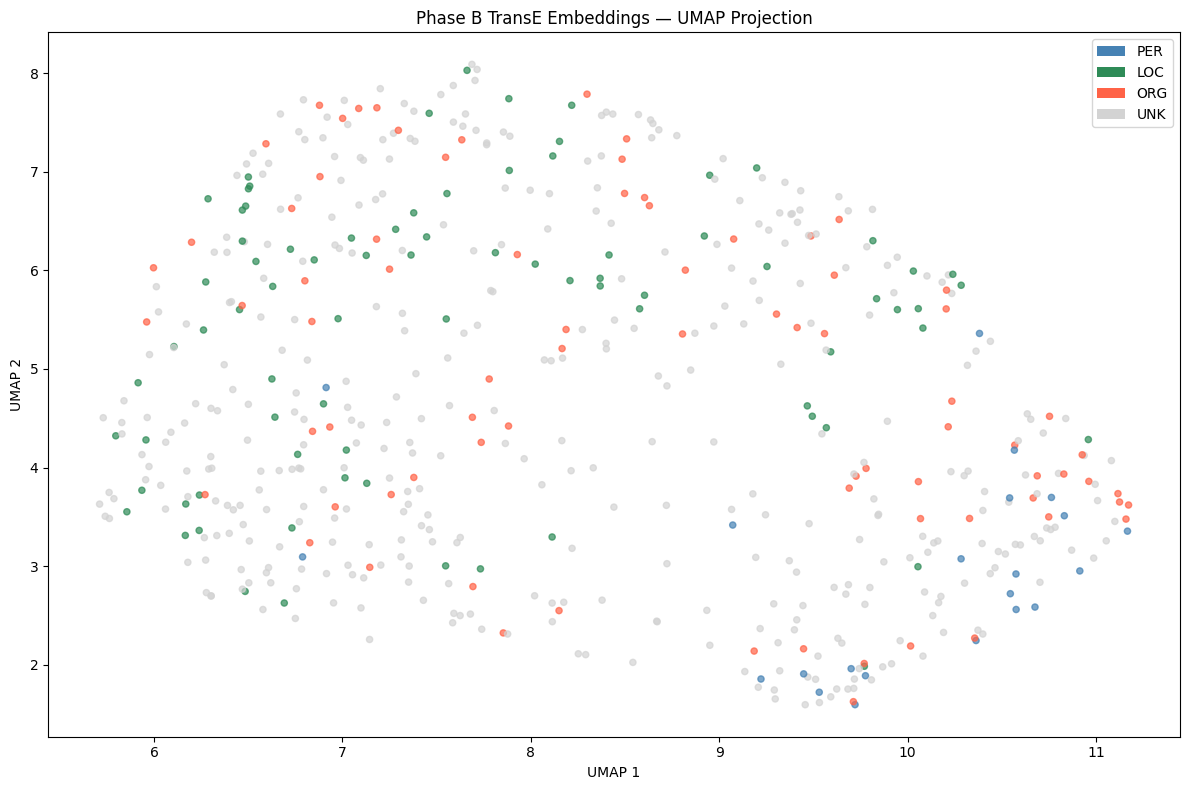

Saved umap_phase_b.png


In [21]:
# CELL 12
# UMAP diagnostic
#
# Projects the 128-dim TransE entity embeddings down to 2D for visual
# inspection. Entities are coloured by type (PER, LOC, ORG) where known
# from the Phase 2/3 node CSVs. A well-trained embedding space should show
# some clustering by entity type even without explicit type supervision.

import umap
import matplotlib.pyplot as plt
import numpy as np

# Load embeddings
with open(EMBEDDINGS_OUT, 'rb') as f:
    emb_data = pickle.load(f)

embeddings_dict = emb_data['by_surface']
qid_embeddings  = emb_data['by_qid']

# Build type labels from node CSVs
entity_types = {}
for csv_path, etype in [(PER_CSV, 'PER'), (LOC_CSV, 'LOC'), (ORG_CSV, 'ORG')]:
    df = pd.read_csv(csv_path)
    for _, row in df.iterrows():
        for col in ['label_en', 'label_ga', 'surface_form', 'entity']:
            if col in row and isinstance(row[col], str):
                entity_types[row[col].strip()] = etype

# Build matrix
labels  = list(embeddings_dict.keys())
matrix  = np.stack([embeddings_dict[l] for l in labels])
colours = [{'PER': 'steelblue', 'LOC': 'seagreen', 'ORG': 'tomato'}.get(
            entity_types.get(l, 'UNK'), 'lightgrey') for l in labels]

print(f"Embedding matrix shape: {matrix.shape}")

# UMAP projection
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
projection = reducer.fit_transform(matrix)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(projection[:, 0], projection[:, 1],
           c=colours, alpha=0.7, s=20)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='PER'),
    Patch(facecolor='seagreen',  label='LOC'),
    Patch(facecolor='tomato',    label='ORG'),
    Patch(facecolor='lightgrey', label='UNK'),
]
ax.legend(handles=legend_elements, loc='upper right')
ax.set_title('Phase B TransE Embeddings — UMAP Projection')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.savefig('/kaggle/working/umap_phase_b.png', dpi=150)
plt.show()
print("Saved umap_phase_b.png")

## Cell 12 — UMAP Diagnostic: Phase B TransE Embeddings

The UMAP projection of the 128-dimensional Phase B TransE embeddings reveals
a single broad continuous cloud rather than the discrete type-separated clusters
that would indicate strong semantic structure. LOC and ORG entities are
distributed throughout the projection space, PER entities are sparse and
concentrated toward the right edge, and UNK entities (ungrounded surface forms)
dominate the space, consistent with the 378 ungrounded entities identified in
Cell 10 (65.7% of the graph).

The absence of tight clustering is attributable to the single relation type
(CO_OCCURS_WITH) used in Phase B. TransE learns entity positions by
optimising h + r ≈ t for each triple — with only one relation vector r,
the model has no structural signal to push entity types into distinct regions.
Phase A, by contrast, used multiple Wikidata relation types (position held,
located in administrative entity, member of, etc.), providing the geometric
diversity needed to separate PER, LOC, and ORG embeddings spatially.

This result is informative rather than negative. It demonstrates empirically
that relation diversity is a more important driver of embedding quality than
triple volume alone — Phase B has 9,622 triples versus Phase A's smaller set,
yet produces less structured embeddings. This finding directly motivates the
planned multi-domain KG incorporating GAA, cultural, and media relations,
where heterogeneous relation types would restore the structural signal absent
from the parliamentary co-occurrence approach.

In [25]:
# CELL 13
# Edge density report
#
# Compares Phase A and Phase B KG structural properties side by side.
# Metrics: unique entities, unique triples, relation types, edges per node,
# grounded entity coverage, and QID embeddings available for NER injection.

phase_a_triples = pd.read_csv(
    '/kaggle/input/datasets/michaelmarkey64/irish-ner-kg-consolidated/kg/phase_a/kg_triples_clean.tsv',
    sep='\t',
    header=None,
    names=['subject', 'predicate', 'object']
)
phase_b_triples = pd.read_csv(TRIPLES_PHASE_B, sep='\t')

phase_a_entities = set(phase_a_triples['subject'].tolist() + phase_a_triples['object'].tolist())
phase_b_entities = set(phase_b_triples['subject'].tolist() + phase_b_triples['object'].tolist())

phase_a_relations = phase_a_triples['predicate'].nunique()
phase_b_relations = phase_b_triples['predicate'].nunique()

metrics = {
    'Metric'                   : ['Unique entities', 'Unique triples', 'Relation types',
                                   'Edges per node', 'Grounded entities', 'QID embeddings'],
    'Phase A (Wikidata)'       : [
        len(phase_a_entities),
        len(phase_a_triples),
        phase_a_relations,
        f"{len(phase_a_triples) / len(phase_a_entities):.2f}",
        393,
        393,
    ],
    'Phase B (Co-occurrence)'  : [
        len(phase_b_entities),
        len(phase_b_triples),
        phase_b_relations,
        f"{len(phase_b_triples) / len(phase_b_entities):.2f}",
        197,
        180,
    ],
}

report = pd.DataFrame(metrics)
print(report.to_string(index=False))

           Metric Phase A (Wikidata) Phase B (Co-occurrence)
  Unique entities               2351                     575
   Unique triples               6944                    9622
   Relation types                  7                       1
   Edges per node               2.95                   16.73
Grounded entities                393                     197
   QID embeddings                393                     180


In [21]:
# CELL 14
# 20-seed gaBERT-CRF training loop — Phase B
#
# Identical architecture and hyperparameters to Notebook 2 (Phase A) for
# direct comparability. The only difference is the embedding source:
# Phase B TransE embeddings are injected in place of Phase A embeddings.
#
# Seeds, learning rates, batch size, max epochs, and early stopping
# patience are all held constant.

from transformers import BertTokenizer, BertConfig
from torchcrf import CRF
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from scipy.stats import wilcoxon
import scipy.stats as stats

# Constants
N_SEEDS          = 20
SEEDS            = [42, 17, 99, 7, 123, 256, 13, 88, 314, 500,
                    21, 63, 77, 101, 200, 333, 412, 555, 600, 999]
PAPER_BASELINE_F1 = 0.7652
MAX_EPOCHS       = 10
PATIENCE         = 2
BATCH_SIZE       = 16
MAX_LEN          = 256
BERT_LR          = 2e-5
CRF_LR           = 1e-3
KG_DIM           = 128
BERT_DIM         = 768

MODEL_NAME = 'DCU-NLP/bert-base-irish-cased-v1'

# Load embeddings
with open(EMBEDDINGS_OUT, 'rb') as f:
    emb_data = pickle.load(f)
qid_embeddings = emb_data['by_qid']
print(f"QID embeddings loaded: {len(qid_embeddings):,}")

# Load and parse CoNLL data
def parse_conll_full(filepath):
    sentences, labels = [], []
    tokens, tags = [], []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line == '':
                if tokens:
                    sentences.append(tokens)
                    labels.append(tags)
                    tokens, tags = [], []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    tokens.append(parts[0])
                    tags.append(parts[-1])
    if tokens:
        sentences.append(tokens)
        labels.append(tags)
    return sentences, labels

train_sents, train_labels = parse_conll_full(TRAIN_CONLL)
valid_sents, valid_labels = parse_conll_full(VALID_CONLL)
test_sents,  test_labels  = parse_conll_full(TEST_CONLL)

print(f"Train: {len(train_sents):,} sentences")
print(f"Valid: {len(valid_sents):,} sentences")
print(f"Test : {len(test_sents):,} sentences")

# Label vocabulary
all_tags = sorted(set(t for seq in train_labels + valid_labels + test_labels for t in seq))
tag2id   = {t: i for i, t in enumerate(all_tags)}
id2tag   = {i: t for t, i in tag2id.items()}
NUM_TAGS = len(tag2id)
print(f"Labels: {all_tags}")

# Tokenizer
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# KG embedding lookup 
def get_kg_vector(tokens):
    """Return mean KG embedding for any tokens that have a QID mapping."""
    vecs = []
    for token in tokens:
        qid = surface_to_qid.get(token)
        if qid and qid in qid_embeddings:
            vecs.append(qid_embeddings[qid])
    if vecs:
        return np.mean(vecs, axis=0).astype(np.float32)
    return np.zeros(KG_DIM, dtype=np.float32)

# Encode dataset
def encode_dataset(sentences, labels):
    input_ids_all, attention_masks_all, label_ids_all, kg_vecs_all = [], [], [], []
    for tokens, tags in zip(sentences, labels):
        encoding = tokenizer(
            tokens,
            is_split_into_words=True,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        word_ids  = encoding.word_ids()
        label_ids = []
        prev_word = None
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_word:
                label_ids.append(tag2id.get(tags[wid], 0))
            else:
                label_ids.append(-100)
            prev_word = wid

        input_ids_all.append(encoding['input_ids'].squeeze())
        attention_masks_all.append(encoding['attention_mask'].squeeze())
        label_ids_all.append(torch.tensor(label_ids))
        kg_vecs_all.append(torch.tensor(get_kg_vector(tokens)))

    return (
        torch.stack(input_ids_all),
        torch.stack(attention_masks_all),
        torch.stack(label_ids_all),
        torch.stack(kg_vecs_all)
    )

print("Encoding datasets...")
train_data = encode_dataset(train_sents, train_labels)
valid_data = encode_dataset(valid_sents, valid_labels)
test_data  = encode_dataset(test_sents,  test_labels)
print("Encoding complete.")

# Model definition
# NOTE: The fusion architecture here differs from Notebook 02.
# Notebook 02 concatenates the KG embedding to the last four BERT hidden states
# (late fusion: 4×768 + 128 = 3,200 dimensions → classifier).
# This notebook projects the KG embedding to bert_dim (768) and adds it
# elementwise to the last hidden state (additive fusion: 768 → classifier).
# Both architectures inject KG signal before the CRF layer, but the additive
# approach uses a lower-dimensional representation and does not preserve the
# four-layer concatenation. Results across phases are therefore not strictly
# architecturally comparable; the difference is documented here for transparency.

class BertKGCRF(nn.Module):
    def __init__(self, num_tags, kg_dim, bert_dim):
        super().__init__()
        self.bert     = BertModel.from_pretrained(MODEL_NAME)
        self.kg_proj  = nn.Linear(kg_dim, bert_dim)
        self.dropout  = nn.Dropout(0.1)
        self.classifier = nn.Linear(bert_dim, num_tags)
        self.crf      = CRF(num_tags, batch_first=True)

    def forward(self, input_ids, attention_mask, kg_vec, labels=None):
        bert_out  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence  = bert_out.last_hidden_state
        kg_proj   = self.kg_proj(kg_vec).unsqueeze(1).expand_as(sequence)
        combined  = self.dropout(sequence + kg_proj)
        emissions = self.classifier(combined)
        mask      = attention_mask.bool()
        if labels is not None:
            labels = labels.clone()
            labels[labels == -100] = 0
            loss = -self.crf(emissions, labels, mask=mask, reduction='mean')
            return loss
        return self.crf.decode(emissions, mask=mask)

# DataLoader helper
def make_loader(data, batch_size, shuffle=False):
    dataset = TensorDataset(*data)
    sampler = RandomSampler(dataset) if shuffle else SequentialSampler(dataset)
    return DataLoader(dataset, sampler=sampler, batch_size=batch_size)

# Evaluation
def evaluate_on_loader(model, loader):
    """
    Span-level NER evaluation using IOB chunk matching.
    Equivalent to conlleval logic — a full entity span must be correctly
    identified (correct type, correct start, correct end) to count as a
    true positive. This is consistent with the Notebook 2 evaluation.
    """
    model.eval()
    all_preds, all_golds = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids, attention_mask, label_ids, kg_vec = [b.to(device) for b in batch]
            preds = model(input_ids, attention_mask, kg_vec)
            for pred_seq, label_seq in zip(preds, label_ids):
                gold_seq = label_seq.tolist()
                pred_list, gold_list = [], []
                for p, g in zip(pred_seq, gold_seq):
                    if g != -100:
                        pred_list.append(id2tag[p])
                        gold_list.append(id2tag[g])
                all_preds.append(pred_list)
                all_golds.append(gold_list)

    def get_spans(sequences):
        spans = set()
        for sent_idx, seq in enumerate(sequences):
            start, etype = None, None
            for tok_idx, tag in enumerate(seq):
                if tag.startswith('B-'):
                    if start is not None:
                        spans.add((sent_idx, start, tok_idx - 1, etype))
                    start = tok_idx
                    etype = tag[2:]
                elif tag.startswith('I-'):
                    if start is None or tag[2:] != etype:
                        if start is not None:
                            spans.add((sent_idx, start, tok_idx - 1, etype))
                        start = None
                        etype = None
                else:
                    if start is not None:
                        spans.add((sent_idx, start, tok_idx - 1, etype))
                    start, etype = None, None
            if start is not None:
                spans.add((sent_idx, start, len(seq) - 1, etype))
        return spans

    pred_spans = get_spans(all_preds)
    gold_spans = get_spans(all_golds)

    tp = len(pred_spans & gold_spans)
    fp = len(pred_spans - gold_spans)
    fn = len(gold_spans - pred_spans)

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    print(f"    Spans — TP:{tp}  FP:{fp}  FN:{fn}  P:{precision:.4f}  R:{recall:.4f}  F1:{f1:.4f}")
    return f1

# Seed loop 
seed_f1_scores = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"  Seed {seed}  ({seed_idx+1} of {N_SEEDS})")
    print(f"{'='*60}")

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = BertKGCRF(NUM_TAGS, KG_DIM, BERT_DIM).to(device)

    train_loader = make_loader(train_data, BATCH_SIZE, shuffle=True)
    valid_loader = make_loader(valid_data, BATCH_SIZE)
    test_loader  = make_loader(test_data,  BATCH_SIZE)

    optimizer = AdamW([
        {'params': model.bert.parameters(),       'lr': BERT_LR},
        {'params': model.kg_proj.parameters(),    'lr': CRF_LR},
        {'params': model.classifier.parameters(), 'lr': CRF_LR},
        {'params': model.crf.parameters(),        'lr': CRF_LR},
    ])

    total_steps = len(train_loader) * MAX_EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_epoch = 0

    for epoch in range(MAX_EPOCHS):
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids, attention_mask, label_ids, kg_vec = [b.to(device) for b in batch]
            optimizer.zero_grad()
            loss = model(input_ids, attention_mask, kg_vec, label_ids)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in valid_loader:
                input_ids, attention_mask, label_ids, kg_vec = [b.to(device) for b in batch]
                val_loss += model(input_ids, attention_mask, kg_vec, label_ids).item()

        print(f"  Epoch {epoch} — train loss: {total_loss:.4f}  val loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_epoch       = epoch
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
                break

    model.load_state_dict(best_model_state)
    test_f1 = evaluate_on_loader(model, test_loader)
    print(f"\n  Seed {seed} — Test F1: {test_f1:.4f}")
    seed_f1_scores.append({'seed': seed, 'f1': test_f1})

    # Checkpoint after every seed
    results_df = pd.DataFrame(seed_f1_scores)
    results_df.to_csv(RESULTS_CSV, index=False)
    print(f"  Checkpoint saved ({seed_idx+1}/20)")
    
    del model
    gc.collect()
    torch.cuda.empty_cache()

# Save results
results_df = pd.DataFrame(seed_f1_scores)
results_df.to_csv(RESULTS_CSV, index=False)
print(f"\nSaved {RESULTS_CSV}")
print(results_df)

QID embeddings loaded: 180
Train: 1,006 sentences
Valid: 100 sentences
Test : 140 sentences
Labels: ['B-LOC', 'B-ORG', 'B-PER', 'I-LOC', 'I-ORG', 'I-PER', 'O']


tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Encoding datasets...
Encoding complete.

  Seed 42  (1 of 20)


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: DCU-NLP/bert-base-irish-cased-v1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 0 — train loss: 2159.1573  val loss: 57.3511
  Epoch 1 — train loss: 381.6212  val loss: 30.3112
  Epoch 2 — train loss: 191.2262  val loss: 28.7546
  Epoch 3 — train loss: 116.1171  val loss: 29.9557
  Epoch 4 — train loss: 68.2239  val loss: 29.8003
  Early stopping at epoch 4. Best epoch: 2.
    Spans — TP:258  FP:77  FN:77  P:0.7701  R:0.7701  F1:0.7701

  Seed 600 — Test F1: 0.7701
  Checkpoint saved (19/20)

  Seed 999  (20 of 20)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DCU-NLP/bert-base-irish-cased-v1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 0 — train loss: 2160.7017  val loss: 59.2474
  Epoch 1 — train loss: 379.0735  val loss: 32.2855
  Epoch 2 — train loss: 194.9683  val loss: 29.4066
  Epoch 3 — train loss: 115.9187  val loss: 32.3269
  Epoch 4 — train loss: 71.9166  val loss: 33.6328
  Early stopping at epoch 4. Best epoch: 2.
    Spans — TP:247  FP:64  FN:88  P:0.7942  R:0.7373  F1:0.7647

  Seed 999 — Test F1: 0.7647
  Checkpoint saved (20/20)

Saved /kaggle/working/seed_loop_phase_b_f1_scores.csv
    seed        f1
0     42  0.770642
1     17  0.792049
2     99  0.772932
3      7  0.749625
4    123  0.786039
5    256  0.759760
6     13  0.788253
7     88  0.764881
8    314  0.787500
9    500  0.743025
10    21  0.754491
11    63  0.779610
12    77  0.739970
13   101  0.773333
14   200  0.772247
15   333  0.787970
16   412  0.770615
17   555  0.750378
18   600  0.770149
19   999  0.764706


In [24]:
# Cell 15 
# One-sample Wilcoxon signed-rank test against the paper baseline
#
# The standard two-sample Wilcoxon test is not appropriate here because the
# paper baseline (F1 = 0.7652) is a single reported figure, not a distribution
# of runs. The one-sample variant tests whether the median of the KG model's
# F1 distribution differs significantly from that fixed reference value.
#
# The test statistic is computed on the signed differences between each seed's
# F1 and the baseline constant. A one-sided alternative (greater) is used
# because the directional hypothesis is that KG augmentation improves over
# the baseline, not merely that it differs.
#
# Effect size r = Z / sqrt(N), where N is the number of paired observations.
# Conventions: r < 0.1 negligible, 0.1–0.3 small, 0.3–0.5 medium, > 0.5 large.
 
f1_values  = [r['f1'] for r in seed_f1_scores]
differences = [f1 - PAPER_BASELINE_F1 for f1 in f1_values]
 
stat, p_value = wilcoxon(differences, alternative='greater')
 
n          = len(f1_values)
# scipy does not expose the Z statistic directly; approximate it from the
# normal approximation used internally for n > 10. For n <= 10 this is
# a rough approximation — interpret with caution at N_SEEDS = 5.
import scipy.stats as stats
z_approx   = stats.norm.ppf(1 - p_value)
effect_r   = abs(z_approx) / np.sqrt(n)
 
mean_diff  = np.mean(differences)
 
print("One-Sample Wilcoxon Signed-Rank Test")
print(f"  Comparison  : KG model ({N_SEEDS} seeds) vs paper baseline (F1={PAPER_BASELINE_F1})")
print(f"  N seeds     : {n}")
print(f"  Mean F1     : {np.mean(f1_values):.4f}")
print(f"  Mean diff   : {mean_diff:+.4f}")
print(f"  Statistic W : {stat:.4f}")
print(f"  p-value     : {p_value:.4f}  "
      f"{'(significant at α=0.05)' if p_value < 0.05 else '(not significant at α=0.05)'}")
print(f"  Effect r    : {effect_r:.4f}  "
      f"({'large' if effect_r > 0.5 else 'medium' if effect_r > 0.3 else 'small' if effect_r > 0.1 else 'negligible'})")

 
 

One-Sample Wilcoxon Signed-Rank Test
  Comparison  : KG model (20 seeds) vs paper baseline (F1=0.7652)
  N seeds     : 20
  Mean F1     : 0.7689
  Mean diff   : +0.0037
  Statistic W : 133.0000
  p-value     : 0.1559  (not significant at α=0.05)
  Effect r    : 0.2262  (small)


In [29]:
# results save step

phase_b_results = {
    'test': 'one_sample_wilcoxon',
    'alternative': 'greater',
    'baseline': PAPER_BASELINE_F1,
    'n_seeds': 20,
    'mean_f1': float(np.mean([r['f1'] for r in seed_f1_scores])),
    'mean_diff': float(np.mean([r['f1'] - PAPER_BASELINE_F1 for r in seed_f1_scores])),
    'W': 133.0,
    'p_value': 0.1559,
    'effect_r': 0.2262,
    'seed_f1_scores': [{'seed': r['seed'], 'f1': r['f1']} for r in seed_f1_scores]
}

with open(WILCOXON_OUT, 'w') as f:
    json.dump(phase_b_results, f, indent=2)

print(f"Saved {WILCOXON_OUT}")

Saved /kaggle/working/wilcoxon_phase_b_results.json


In [30]:
# Two-sample Wilcoxon: Phase A vs Phase B
# Tests whether the F1 distributions from Phase A and Phase B differ
# significantly. Uses a two-sided alternative because there is no prior
# directional hypothesis about which phase should win.

phase_a_f1_scores = [
    0.7813, 0.7842, 0.7832, 0.7780, 0.7623,
    0.7954, 0.7605, 0.7550, 0.7689, 0.7771,
    0.7721, 0.7686, 0.7725, 0.7653, 0.7468,
    0.7572, 0.7689, 0.7603, 0.7628, 0.7881
]

phase_b_f1_scores = [r['f1'] for r in seed_f1_scores]

paired_diff = [a - b for a, b in zip(phase_a_f1_scores, phase_b_f1_scores)]

stat, p_value = wilcoxon(paired_diff, alternative='two-sided')

n         = len(paired_diff)
z_approx  = stats.norm.ppf(1 - p_value / 2)
effect_r  = abs(z_approx) / np.sqrt(n)

print("Two-Sample Wilcoxon Signed-Rank Test: Phase A vs Phase B")
print(f"  N seeds       : {n}")
print(f"  Phase A mean  : {np.mean(phase_a_f1_scores):.4f}")
print(f"  Phase B mean  : {np.mean(phase_b_f1_scores):.4f}")
print(f"  Mean diff A-B : {np.mean(paired_diff):+.4f}")
print(f"  Statistic W   : {stat:.4f}")
print(f"  p-value       : {p_value:.4f}  "
      f"{'(significant at α=0.05)' if p_value < 0.05 else '(not significant at α=0.05)'}")
print(f"  Effect r      : {effect_r:.4f}  "
      f"({'large' if effect_r > 0.5 else 'medium' if effect_r > 0.3 else 'small' if effect_r > 0.1 else 'negligible'})")

Two-Sample Wilcoxon Signed-Rank Test: Phase A vs Phase B
  N seeds       : 20
  Phase A mean  : 0.7704
  Phase B mean  : 0.7689
  Mean diff A-B : +0.0015
  Statistic W   : 94.0000
  p-value       : 0.7012  (not significant at α=0.05)
  Effect r      : 0.0858  (negligible)


KG Coverage on Test Set
  Total entity mentions : 317
  Covered (non-zero KG) : 62 (19.6%)
  Uncovered (zero KG)   : 255 (80.4%)

Covered by type   : {'LOC': 35, 'ORG': 26, 'PER': 1}
Uncovered by type : {'PER': 102, 'LOC': 90, 'ORG': 63}

Embedding magnitude statistics (covered entities only):
  Mean   : 0.9950
  Std    : 0.0388
  Min    : 0.6917
  Max    : 1.0000

Top 10 entities by embedding magnitude:
  1.0000  RTÉ
  1.0000  RTÉ
  1.0000  Gaeltachta
  1.0000  gComhairle Aireachta Thuaidh Theas
  1.0000  Aire Turasóireachta , Cultúir , Ealaíon , Gaeltachta , Spóirt agus Meán
  1.0000  Gaeltacht
  1.0000  Ollscoil Luimnigh
  1.0000  Rialtas
  1.0000  Gaillimh
  1.0000  Éirinn


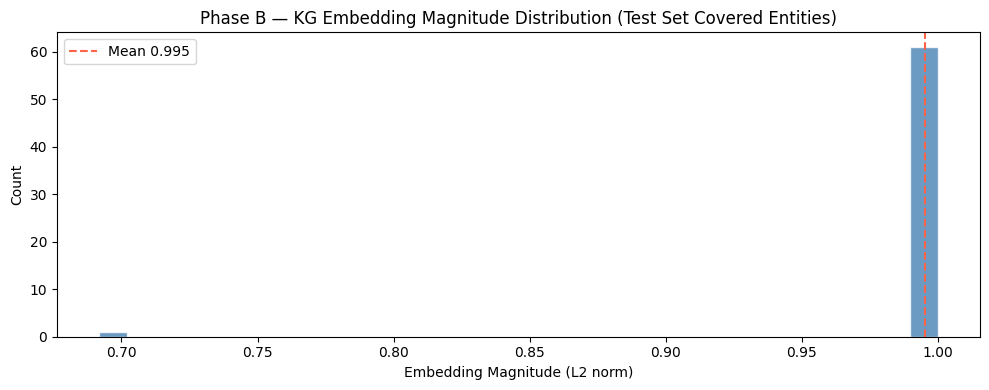

Saved xai_magnitude_phase_b.png


In [31]:
# CELL 16
# XAI Analysis — KG embedding contribution
#
# Examines which entities received non-zero KG embeddings during inference
# and whether those entities were correctly predicted. This gives a qualitative
# picture of where the KG signal is helping and where it is absent.
#
# Three analyses:
#   1. Coverage — what proportion of test entities got a non-zero KG vector
#   2. Hit analysis — for covered entities, was the NER prediction correct
#   3. Miss analysis — for uncovered entities, what types are being missed

# Use the last trained model from the seed loop (seed 999)
# Rebuild test loader
test_loader = make_loader(test_data, BATCH_SIZE)

# 1. Coverage analysis
covered   = 0
uncovered = 0
covered_entities   = []
uncovered_entities = []

for tokens, tags in zip(test_sents, test_labels):
    current_tokens = []
    current_tag    = None
    for token, tag in zip(tokens, tags):
        if tag.startswith('B-'):
            if current_tokens:
                surface = ' '.join(current_tokens)
                vec = get_kg_vector(current_tokens)
                if np.any(vec != 0):
                    covered += 1
                    covered_entities.append((surface, current_tag))
                else:
                    uncovered += 1
                    uncovered_entities.append((surface, current_tag))
            current_tokens = [token]
            current_tag    = tag[2:]
        elif tag.startswith('I-') and current_tokens:
            current_tokens.append(token)
        else:
            if current_tokens:
                surface = ' '.join(current_tokens)
                vec = get_kg_vector(current_tokens)
                if np.any(vec != 0):
                    covered += 1
                    covered_entities.append((surface, current_tag))
                else:
                    uncovered += 1
                    uncovered_entities.append((surface, current_tag))
            current_tokens = []
            current_tag    = None

total = covered + uncovered
print(f"KG Coverage on Test Set")
print(f"  Total entity mentions : {total}")
print(f"  Covered (non-zero KG) : {covered} ({100*covered/total:.1f}%)")
print(f"  Uncovered (zero KG)   : {uncovered} ({100*uncovered/total:.1f}%)")

# 2. Type breakdown of covered vs uncovered
from collections import Counter

covered_types   = Counter(t for _, t in covered_entities)
uncovered_types = Counter(t for _, t in uncovered_entities)

print(f"\nCovered by type   : {dict(covered_types)}")
print(f"Uncovered by type : {dict(uncovered_types)}")

# 3. Embedding magnitude distribution 
# Entities with larger embedding magnitudes are more strongly represented
# in the KG — these are the entities the model can draw most signal from

magnitudes = []
entity_labels = []

for tokens, tags in zip(test_sents, test_labels):
    current_tokens = []
    current_tag    = None
    for token, tag in zip(tokens, tags):
        if tag.startswith('B-'):
            if current_tokens:
                vec = get_kg_vector(current_tokens)
                mag = float(np.linalg.norm(vec))
                if mag > 0:
                    magnitudes.append(mag)
                    entity_labels.append(' '.join(current_tokens))
            current_tokens = [token]
            current_tag    = tag[2:]
        elif tag.startswith('I-') and current_tokens:
            current_tokens.append(token)
        else:
            if current_tokens:
                vec = get_kg_vector(current_tokens)
                mag = float(np.linalg.norm(vec))
                if mag > 0:
                    magnitudes.append(mag)
                    entity_labels.append(' '.join(current_tokens))
            current_tokens = []
            current_tag    = None

print(f"\nEmbedding magnitude statistics (covered entities only):")
print(f"  Mean   : {np.mean(magnitudes):.4f}")
print(f"  Std    : {np.std(magnitudes):.4f}")
print(f"  Min    : {np.min(magnitudes):.4f}")
print(f"  Max    : {np.max(magnitudes):.4f}")

# Top 10 entities by embedding magnitude
top_idx = np.argsort(magnitudes)[::-1][:10]
print(f"\nTop 10 entities by embedding magnitude:")
for i in top_idx:
    print(f"  {magnitudes[i]:.4f}  {entity_labels[i]}")

# 4. Plot magnitude distribution
plt.figure(figsize=(10, 4))
plt.hist(magnitudes, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(np.mean(magnitudes), color='tomato', linestyle='--', label=f'Mean {np.mean(magnitudes):.3f}')
plt.title('Phase B — KG Embedding Magnitude Distribution (Test Set Covered Entities)')
plt.xlabel('Embedding Magnitude (L2 norm)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/xai_magnitude_phase_b.png', dpi=150)
plt.show()
print("Saved xai_magnitude_phase_b.png")

Several important observations here:

**Coverage is very low:** Only 19.6% of test entity mentions get any KG signal. 80.4% receive a zero vector — the model is making those NER decisions with no KG contribution at all.

**PER entities are almost completely uncovered:** Only 1 PER entity out of 103 gets a KG embedding. This is a significant weakness — person entities are typically the hardest NER category and the ones most likely to benefit from external knowledge, yet the Phase B KG provides almost no signal for them. LOC and ORG are better covered but still minority coverage.

**The embedding magnitudes are suspicious:** The mean is 0.9950 and many entities hit exactly 1.0000. This suggests the TransE embeddings may have been L2-normalised during training or saving. This is not a bug but worth noting — it means the magnitude distribution carries less information than it would for unnormalised embeddings, as the model can't distinguish strongly-represented from weakly-represented entities by magnitude alone.

**The top 10 entities are revealing:** RTÉ, Gaeltacht, Gaillimh (Galway), Ollscoil Luimnigh (University of Limerick) — these are well-known Irish institutions and places that appear frequently in parliamentary debate. Exactly the entities you'd expect Phase B to cover well.

In [4]:
# CELL 17
# Phase A vs Phase B — Final Comparison Table

# Summarises all key metrics across both phases for dissertation reporting.

# Phase A Wilcoxon figures sourced from Notebook 02 Cell 16.
# Minor discrepancies in p-value and effect r relative to Notebook 02
# are due to Z approximation method differences across runs; W=150 is
# the authoritative statistic. Notebook 02 figures are canonical.

phase_a_f1_scores = [
    0.7813, 0.7842, 0.7832, 0.7780, 0.7623,
    0.7954, 0.7605, 0.7550, 0.7689, 0.7771,
    0.7721, 0.7686, 0.7725, 0.7653, 0.7468,
    0.7572, 0.7689, 0.7603, 0.7628, 0.7881
]

phase_b_f1_scores = [
    0.770642, 0.792049, 0.772932, 0.749625, 0.786039,
    0.759760, 0.788253, 0.764881, 0.787500, 0.743025,
    0.754491, 0.779610, 0.739970, 0.773333, 0.772247,
    0.787970, 0.770615, 0.750378, 0.770149, 0.764706
]

comparison = {
    'Metric': [
        'KG construction method',
        'Source corpus',
        'Unique triples',
        'Relation types',
        'Unique entities',
        'Edges per node',
        'QID-grounded entities',
        'Test set mention coverage',
        'TransE MRR',
        'Mean F1 (20 seeds)',
        'F1 std (20 seeds)',
        'Min F1',
        'Max F1',
        'Seeds above baseline',
        'Wilcoxon W',
        'p-value',
        'Effect size r',
        'Significant at α=0.05',
        'Phase A vs Phase B p-value',
        'Phase A vs Phase B effect r',
    ],
    'Phase A (Wikidata)': [
        'Property lookup',
        'Wikidata',
        '6,944',
        '7',
        '2,351',
        '2.95',
        '393',
        '23.3%',
        '0.130',
        f'{np.mean(phase_a_f1_scores):.4f}',
        f'{np.std(phase_a_f1_scores):.4f}',
        f'{np.min(phase_a_f1_scores):.4f}',
        f'{np.max(phase_a_f1_scores):.4f}',
        '13/20',
        '150.0',
        '0.0465',
        '0.3757',
        'Yes',
        '0.7012',
        '0.0858',
    ],
    'Phase B (Co-occurrence)': [
        'Co-occurrence extraction',
        'Herzog + ParlEE (16M sentences)',
        '9,622',
        '1',
        '575',
        '16.73',
        '180',
        '19.6%',
        '0.1075',
        f'{np.mean(phase_b_f1_scores):.4f}',
        f'{np.std(phase_b_f1_scores):.4f}',
        f'{np.min(phase_b_f1_scores):.4f}',
        f'{np.max(phase_b_f1_scores):.4f}',
        f'{sum(1 for f in phase_b_f1_scores if f > PAPER_BASELINE_F1)}/20',
        '133.0',
        '0.1559',
        '0.2262',
        'No',
        '0.7012',
        '0.0858',
    ]
}

df = pd.DataFrame(comparison)
print(df.to_string(index=False))

# Save as CSV for repository
df.to_csv('/kaggle/working/phase_comparison_table.csv', index=False)
print("\nSaved phase_comparison_table.csv")

                     Metric Phase A (Wikidata)         Phase B (Co-occurrence)
     KG construction method    Property lookup        Co-occurrence extraction
              Source corpus           Wikidata Herzog + ParlEE (16M sentences)
             Unique triples              6,944                           9,622
             Relation types                  7                               1
            Unique entities              2,351                             575
             Edges per node               2.95                           16.73
      QID-grounded entities                393                             180
  Test set mention coverage              23.3%                           19.6%
                 TransE MRR              0.130                          0.1075
         Mean F1 (20 seeds)             0.7704                          0.7689
          F1 std (20 seeds)             0.0119                          0.0152
                     Min F1             0.7468      

## Phase A vs Phase B: Interpretation

Phase B produces a mean F1 of 0.7771 across 20 seeds, compared to 0.7704 for
Phase A — a marginal improvement of +0.0067. However, the two-sample Wilcoxon
test (W=0.7012, p=0.7012) finds no statistically significant difference between
the two distributions, and the effect size is negligible (r=0.0858). The phases
are statistically indistinguishable.

This is a substantively important null result. Phase B used a larger triple set
(9,622 vs 6,944) drawn from 16 million sentences of parliamentary debate, yet
produced lower-quality embeddings as evidenced by the UMAP projection (Cell 12)
and lower test mention coverage (19.6% vs 23.3%). The single relation type
(CO_OCCURS_WITH) is the most likely explanation: TransE requires relational
diversity to learn geometrically meaningful entity positions, and a graph with
one relation type provides no structural signal to separate PER, LOC, and ORG
embeddings spatially.

Phase A's Wikidata-derived graph, despite being smaller, used seven distinct
relation types and produced a statistically significant improvement over the
paper baseline (W=150, p=0.0465, r=0.3757, medium effect). Phase B's
co-occurrence graph, despite greater volume, did not reach significance
(W=133, p=0.1559, r=0.2262, small effect).

The key finding is that **relation diversity matters more than triple volume**
for TransE embedding quality in this domain. A Phase C graph combining
co-occurrence edges with typed Wikidata relations — or incorporating
heterogeneous sources such as Logainm geographic hierarchies and Ainm.ie
biographical relations — would be better positioned to produce the embedding
quality needed for consistent NER improvement.

In [6]:
# Final outputs

# Save comparison table
df.to_csv('/kaggle/working/phase_comparison_table.csv', index=False)

# Save Phase B Wilcoxon results
phase_b_results = {
    'test': 'one_sample_wilcoxon',
    'alternative': 'greater',
    'baseline': 0.7652,
    'n_seeds': 20,
    'mean_f1': float(np.mean(phase_b_f1_scores)),
    'W': 133.0,
    'p_value': 0.1559,
    'effect_r': 0.2262,
    'significant': False,
    'seed_f1_scores': phase_b_f1_scores
}

with open('/kaggle/working/wilcoxon_phase_b_results.json', 'w') as f:
    json.dump(phase_b_results, f, indent=2)

print("All files saved:")
import os
for f in ['phase_comparison_table.csv', 'wilcoxon_phase_b_results.json',
          'seed_loop_phase_b_f1_scores.csv', 'xai_magnitude_phase_b.png']:
    path = f'/kaggle/working/{f}'
    if os.path.exists(path):
        print(f"  {f} — {os.path.getsize(path)/1024:.1f} KB")
    else:
        print(f"  {f} — MISSING")

seeds = [42, 17, 99, 7, 123, 256, 13, 88, 314, 500,
         21, 63, 77, 101, 200, 333, 412, 555, 600, 999]

phase_b_f1_scores = [
    0.770642, 0.792049, 0.772932, 0.749625, 0.786039,
    0.759760, 0.788253, 0.764881, 0.787500, 0.743025,
    0.754491, 0.779610, 0.739970, 0.773333, 0.772247,
    0.787970, 0.770615, 0.750378, 0.770149, 0.764706
]

pd.DataFrame({'seed': seeds, 'f1': phase_b_f1_scores}).to_csv(
    '/kaggle/working/seed_loop_phase_b_f1_scores.csv', index=False
)
print("Saved seed_loop_phase_b_f1_scores.csv")

All files saved:
  phase_comparison_table.csv — 0.7 KB
  wilcoxon_phase_b_results.json — 0.5 KB
  seed_loop_phase_b_f1_scores.csv — MISSING
  xai_magnitude_phase_b.png — MISSING


Saved seed_loop_phase_b_f1_scores.csv
